<a href="https://colab.research.google.com/github/estebanurrutia1/Analitica/blob/main/Final_abril23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Librerías para la carga y visualización de las características de los datos**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Librerías para etapa de preprocesamiento y transformación de las reseñas**

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

**Librerías para el modelamiento de los datos**

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

**Librerías para evaluacion del modelo**

In [4]:
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

In [5]:
"""

Se carga la base de datos. Hay que tener cuidado con la ruta o ubicación
del archivo. Para el presente caso se cargó directamente en Colab

"""

df = pd.read_csv("yelp.csv")

In [6]:
# Se revisa la estructura del archivo

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [7]:
# Se revisan las primeras filas del archivo para darse una idea de qué contiene

df.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [8]:
# Se revisa si hay valores nulos en las variables

df.isnull().sum()

,0
business_id,0
date,0
review_id,0
stars,0
text,0
type,0
user_id,0
cool,0
useful,0
funny,0


In [9]:
# Se revisa la variable reviewText para analizar el tratamiento que requiere posrteriormente

df['text'].head()

,text
0,My wife took me here on my birthday for breakf...
1,I have no idea why some people give bad review...
2,love the gyro plate. Rice is so good and I als...
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!..."
4,General Manager Scott Petello is a good egg!!!...


In [10]:
# Se rewvisa la distribución de las calificaciones de los clientes

df['stars'].value_counts()

,count
stars,
4,3526
5,3337
3,1461
2,927
1,749


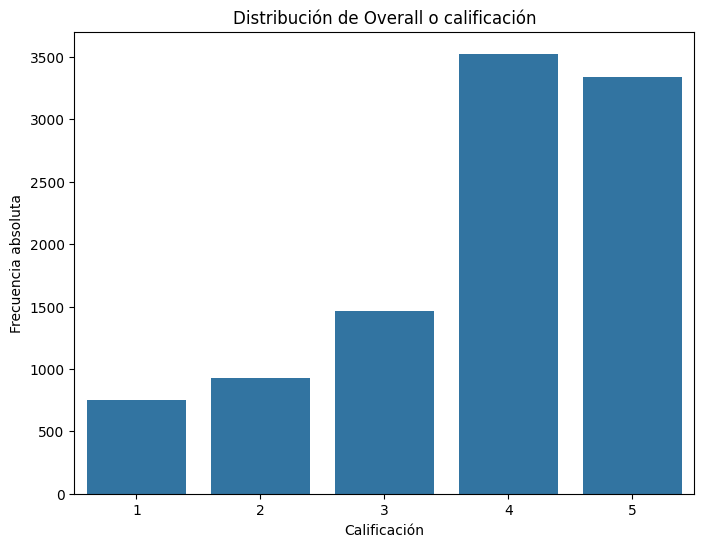

In [12]:
# Visualización de la distribución de las calificaciones de los clientes en la columna overall

plt.figure(figsize=(8, 6))
sns.countplot(x='stars', data=df)
plt.title('Distribución de Overall o calificación')
plt.xlabel('Calificación')
plt.ylabel('Frecuencia absoluta')
plt.show()

In [13]:
# Se observa cómo son las reseñas y la calificación dada por el cliente

df[['text', 'stars']].head()

,text,stars
0,My wife took me here on my birthday for breakf...,5
1,I have no idea why some people give bad review...,5
2,love the gyro plate. Rice is so good and I als...,4
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",5
4,General Manager Scott Petello is a good egg!!!...,5


In [14]:
# Se realiza el Preprocesamiento, tokenizando y lematizando la variable reviewText

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if isinstance(text, str):
        tokens = word_tokenize(text.lower())
        tokens = [word for word in tokens if word.isalpha()]
        tokens = [word for word in tokens if word not in stop_words]
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        return " ".join(tokens)
    return ""

df['clean_text'] = df['text'].apply(preprocess_text)

# Se eliminan las filas donde hay textos vacíos

df = df[df['clean_text'].str.strip() != ""].copy()

In [15]:
# Para ilustración, las stopwords se muestran a continuación

stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [16]:
# Se muestran ejemplos del texto transformado

df[['text', 'clean_text']].head()

,text,clean_text
0,My wife took me here on my birthday for breakf...,wife took birthday breakfast excellent weather...
1,I have no idea why some people give bad review...,idea people give bad review place go show plea...
2,love the gyro plate. Rice is so good and I als...,love gyro plate rice good also dig candy selec...
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",rosie dakota love chaparral dog park convenien...
4,General Manager Scott Petello is a good egg!!!...,general manager scott petello good egg go deta...


**Nota**

Las reseñas de Amazon vienen rankeadas de 1 a 5. La categoría negativa se da cuando el rating proporcionado por el usuario es igual o menor que 3 y positiva si es igual o mayor a 4. Se utiliza la siguiente línea de código:

In [17]:
# Se organizan las Etiquetas o calificaciones en dos categorias

df['label'] = df['stars'].apply(lambda x: 1 if x >= 4 else 0)

In [18]:
# Se organizan las Variables con las que se va a trabajar el modelamiento

X = df['clean_text']
y = df['label']

In [19]:
#  Se observa los valores de la nueva variable para terner claridad de qué se trata

y.head()

,label
0,1
1,1
2,1
3,1
4,1


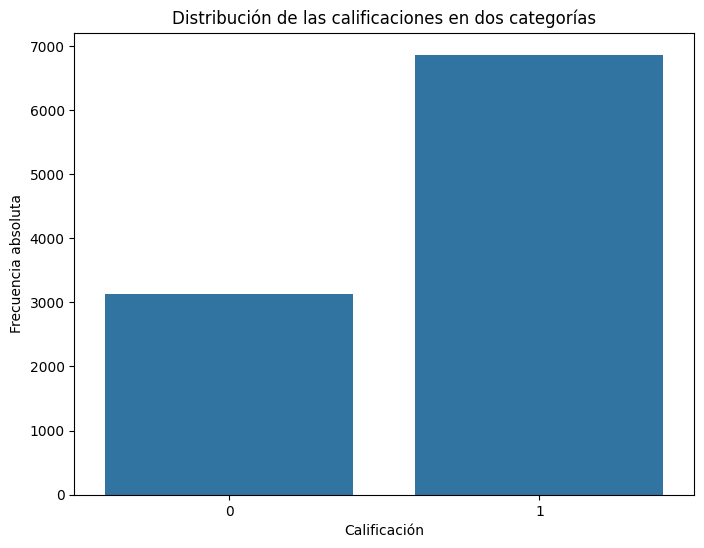

In [20]:
# Visualización de la distribución del sentimiento en la columna overall

plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df)
plt.title('Distribución de las calificaciones en dos categorías')
plt.xlabel('Calificación')
plt.ylabel('Frecuencia absoluta')
plt.show()

In [21]:
# Se realiza el Balanceo

oversampler = RandomOverSampler(random_state=42)
X_balanced, y_balanced = oversampler.fit_resample(X.to_frame(), y)
X_balanced = X_balanced['clean_text']

In [22]:
# Se entrena el modelo

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

In [23]:
# Se aplica la técnica de TF-IDF

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [24]:
# Se aplica una regresión logística al Modelo

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

**Nota:**


Para el análisis, coviene recodar que las reseñas de Amazon vienen rankeadas de 1 a 5. La categoría negativa se da cuando el rating proporcionado por el usuario es igual o menor que 3 y positiva si es igual o mayor a 4.

In [25]:
# Se evalua el modelo

y_pred = model.predict(X_test_tfidf)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))




Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1345
           1       0.88      0.84      0.86      1401

    accuracy                           0.86      2746
   macro avg       0.86      0.86      0.86      2746
weighted avg       0.86      0.86      0.86      2746



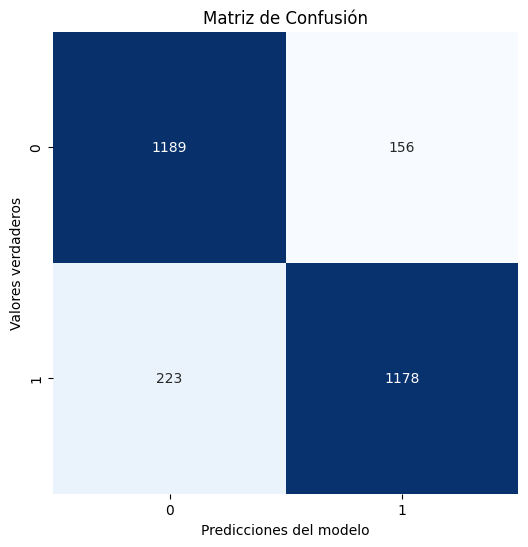

In [26]:
# Se realiza una Matriz de Confusión, para analizar visualmente los falsos positivos y falsos negativos

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicciones del modelo')
plt.ylabel('Valores verdaderos')
plt.title('Matriz de Confusión')
plt.show()

**Como conclusiones se tiene:**

1. Un Pipeline es un paso a paso que permite importar, describir, limpiar, organizar, tokenizar, lematizar, modelar y evaluar un modelo, para establecer la tasa de aciertos y desaciertos del entrenamiento del modelo.

2. Es importante tener claridad de qué recurso usar, lo cual depende de la actividad que se quiera realizar, e inclusive del tipo de datos a manejar.

3. Un factor clave es ir construyendo el modelo, entendiendo cada uno de los pasos y visualizando el resultado que éstos producen.

4. Realizar Pipeline, es una actividad que implica tiempo, análisis y reflexión, no solo de la construcción de código, sino del comportamiento y resultados.

5. Los resultados del modelo de análisis indican un rendimiento con una precisión entre el 93 % y 97 %.

6. Ambas puntuaciones (positivas y negativas), obtuvieron un valor de exactitud del 95 %